# 01 — Exploratory Data Analysis
**Dataset:** Docker Container Escape Attack — Capabilities and System Call Traces  
**Goal:** Understand the structure, distributions, and discriminative features before modelling.

## 0. Imports & config

In [2]:
import re
import collections
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='PuRd', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
SAFE_COLOR   = '#378ADD'   # blue  → safe
UNSAFE_COLOR = '#E24B4A'   # red   → unsafe
PALETTE      = [SAFE_COLOR, UNSAFE_COLOR]

DATA_PATH = '../data/raw/docker-container-attack.csv'
print('Ready.')

Ready.


---
## 1. Load & first look

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (61297, 6)


,ContainerName,AddedCapabilitiesList,DroppedCapabilitiesList,SystemCallsList,ReturnValueList,IsSafe
0,mount_attack_container,[SYS_ADMIN SETGID SETUID CHOWN FOWNER DAC_OVER...,[ALL],61 13 16 14 61 15 0 262 262 262 262 262 262 10...,7 0 0 0 -1 0 833 0 -1 -1 -1 0 0 0 0 0 0 0 0 0 ...,False
1,override,[DAC_OVERRIDE DAC_READ_SEARCH CHOWN SETGID SET...,[ALL],61 13 16 14 61 15 0 262 262 262 262 262 262 10...,7 0 0 0 -1 0 338 0 -1 -1 -1 0 0 0 0 0 0 0 0 0 ...,False
2,process_injection_container,[SYS_PTRACE SETGID SETUID CHOWN FOWNER DAC_OVE...,[ALL],61 13 16 14 61 15 0 5 1 14 14 8 56 14 14 14 14...,5044 0 0 0 -1 0 357 0 5 0 0 282 5107 0 0 0 0 0...,False


In [4]:
df.dtypes

ContainerName               str
AddedCapabilitiesList       str
DroppedCapabilitiesList     str
SystemCallsList             str
ReturnValueList             str
IsSafe                     bool
dtype: object

In [5]:
# ── Missing values ────────────────────────────────────────────────────────────
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(3)
pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})

,null_count,null_%
ContainerName,0,0.000
AddedCapabilitiesList,1,0.002
DroppedCapabilitiesList,2,0.003
SystemCallsList,12,0.020
ReturnValueList,8,0.013
IsSafe,0,0.000


**Observation:** Fewer than 12 nulls across 61 K rows — negligible. We will drop them during preprocessing.

---
## 2. Target variable — `IsSafe`

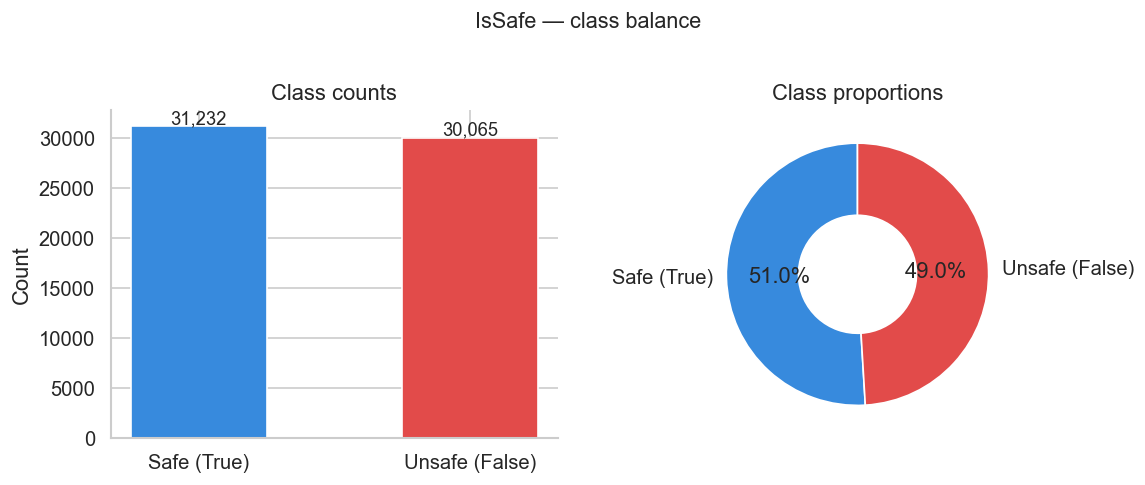

IsSafe
True     31232
False    30065
Name: count, dtype: int64

Imbalance ratio: 1.039x  (near-perfect balance — no SMOTE needed)


In [6]:
counts = df['IsSafe'].value_counts()
labels = ['Safe (True)', 'Unsafe (False)']
colors = [SAFE_COLOR, UNSAFE_COLOR]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar
axes[0].bar(labels, counts.values, color=colors, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)
axes[0].set_ylabel('Count')
axes[0].set_title('Class counts')

# Pie
axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55)   # donut
)
axes[1].set_title('Class proportions')

plt.suptitle('IsSafe — class balance', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/01_class_balance.png', bbox_inches='tight')
plt.show()

print(counts)
print(f'\nImbalance ratio: {counts.max()/counts.min():.3f}x  (near-perfect balance — no SMOTE needed)')

---
## 3. `ContainerName` — attack-type distribution

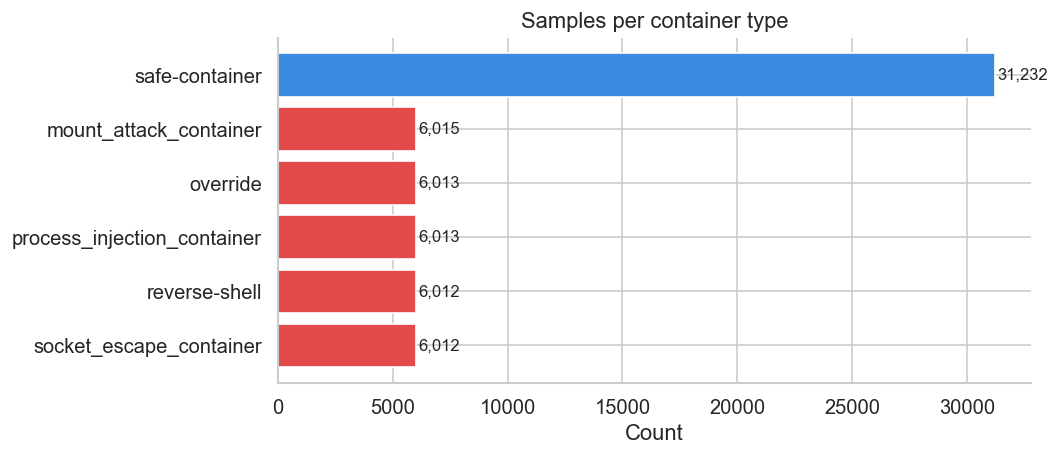

              ContainerName  count
             safe-container  31232
     mount_attack_container   6015
                   override   6013
process_injection_container   6013
              reverse-shell   6012
    socket_escape_container   6012


In [7]:
name_counts = df['ContainerName'].value_counts().reset_index()
name_counts.columns = ['ContainerName', 'count']

# Colour: safe-container → blue, all attack containers → red
bar_colors = [
    SAFE_COLOR if n == 'safe-container' else UNSAFE_COLOR
    for n in name_counts['ContainerName']
]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(name_counts['ContainerName'], name_counts['count'], color=bar_colors)
for bar, v in zip(bars, name_counts['count']):
    ax.text(v + 100, bar.get_y() + bar.get_height() / 2,
            f'{v:,}', va='center', fontsize=10)
ax.set_xlabel('Count')
ax.set_title('Samples per container type')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../results/figures/02_container_distribution.png', bbox_inches='tight')
plt.show()

print(name_counts.to_string(index=False))

**Observation:** Each attack type contributes ~6 000 samples — perfectly balanced across attack categories.

---
## 4. System calls — `SystemCallsList`

Each cell is a **space-separated string of integer syscall IDs**. No non-numeric tokens were found in this column.

In [8]:
# ── Parse syscall sequences ───────────────────────────────────────────────────
df_sc = df.dropna(subset=['SystemCallsList']).copy()
df_sc['syscall_list']   = df_sc['SystemCallsList'].apply(lambda x: list(map(int, str(x).strip().split())))
df_sc['syscall_len']    = df_sc['syscall_list'].apply(len)
df_sc['syscall_unique'] = df_sc['syscall_list'].apply(lambda x: len(set(x)))

stats = df_sc.groupby('IsSafe')[['syscall_len', 'syscall_unique']].describe().round(1)
print(stats)

       syscall_len                                                  \
             count   mean    std   min    25%    50%    75%    max   
IsSafe                                                               
False      30053.0  199.4  111.1  26.0  112.0  202.0  312.0  364.0   
True       31232.0  100.6   22.5  10.0   87.0  105.0  115.0  142.0   

       syscall_unique                                          
                count  mean  std  min   25%   50%   75%   max  
IsSafe                                                         
False         30053.0  19.4  3.9  9.0  17.0  21.0  22.0  24.0  
True          31232.0  19.2  2.6  7.0  17.0  21.0  21.0  23.0  


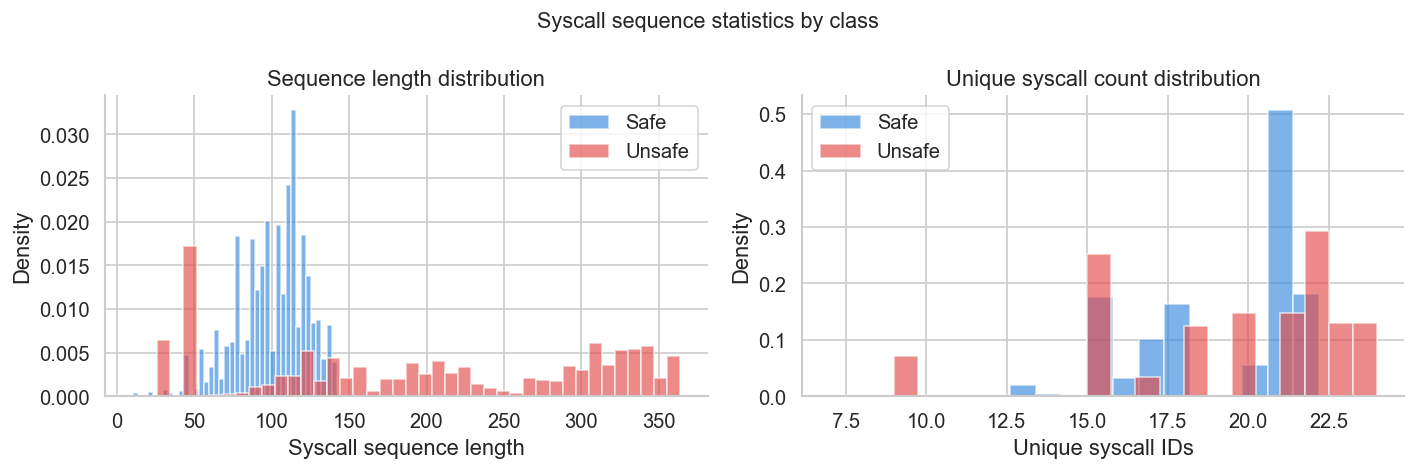

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sequence length distribution
for is_safe, color, label in [(True, SAFE_COLOR, 'Safe'), (False, UNSAFE_COLOR, 'Unsafe')]:
    sub = df_sc[df_sc['IsSafe'] == is_safe]['syscall_len']
    axes[0].hist(sub, bins=40, alpha=0.65, color=color, label=label, density=True)
axes[0].set_xlabel('Syscall sequence length')
axes[0].set_ylabel('Density')
axes[0].set_title('Sequence length distribution')
axes[0].legend()

# Unique syscall count distribution
for is_safe, color, label in [(True, SAFE_COLOR, 'Safe'), (False, UNSAFE_COLOR, 'Unsafe')]:
    sub = df_sc[df_sc['IsSafe'] == is_safe]['syscall_unique']
    axes[1].hist(sub, bins=20, alpha=0.65, color=color, label=label, density=True)
axes[1].set_xlabel('Unique syscall IDs')
axes[1].set_ylabel('Density')
axes[1].set_title('Unique syscall count distribution')
axes[1].legend()

plt.suptitle('Syscall sequence statistics by class', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/03_syscall_length_distributions.png', bbox_inches='tight')
plt.show()

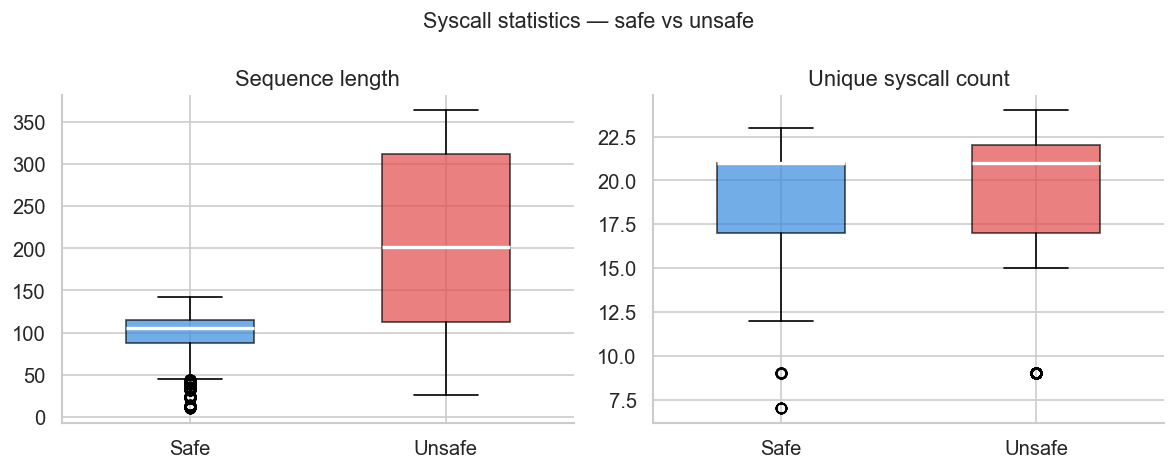

In [10]:
# ── Boxplot comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, title in zip(
    axes,
    ['syscall_len', 'syscall_unique'],
    ['Sequence length', 'Unique syscall count']
):
    data = [df_sc[df_sc['IsSafe'] == True][col].values,
            df_sc[df_sc['IsSafe'] == False][col].values]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], [SAFE_COLOR, UNSAFE_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Safe', 'Unsafe'])
    ax.set_title(title)

plt.suptitle('Syscall statistics — safe vs unsafe', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/04_syscall_boxplots.png', bbox_inches='tight')
plt.show()

**Observations:**
- Unsafe traces are **~2× longer** (mean 199 vs 101 calls). Sequence length alone is a strong feature.
- Both classes have similar unique-syscall counts (~19-20), so the *content* of sequences matters more than how diverse they are.

In [11]:
# ── Per-syscall-ID frequency comparison ──────────────────────────────────────
safe_calls   = collections.Counter()
unsafe_calls = collections.Counter()

for _, row in df_sc.iterrows():
    if row['IsSafe']:
        safe_calls.update(row['syscall_list'])
    else:
        unsafe_calls.update(row['syscall_list'])

# Normalise by number of samples in each class
n_safe   = (df_sc['IsSafe'] == True).sum()
n_unsafe = (df_sc['IsSafe'] == False).sum()

all_ids = sorted(set(safe_calls) | set(unsafe_calls))
safe_freq   = {k: safe_calls[k]   / n_safe   for k in all_ids}
unsafe_freq = {k: unsafe_calls[k] / n_unsafe for k in all_ids}

freq_df = pd.DataFrame({
    'syscall_id'  : all_ids,
    'safe_freq'   : [safe_freq[k]   for k in all_ids],
    'unsafe_freq' : [unsafe_freq[k] for k in all_ids],
})
freq_df['diff']       = freq_df['unsafe_freq'] - freq_df['safe_freq']
freq_df['only_unsafe'] = freq_df['safe_freq'] == 0

print('Syscall IDs exclusive to unsafe traces:')
print(freq_df[freq_df['only_unsafe']][['syscall_id', 'unsafe_freq']])

Syscall IDs exclusive to unsafe traces:
    syscall_id  unsafe_freq
5           12     0.199547
15          80     0.200146
21         109     0.598942
22         111     0.199647


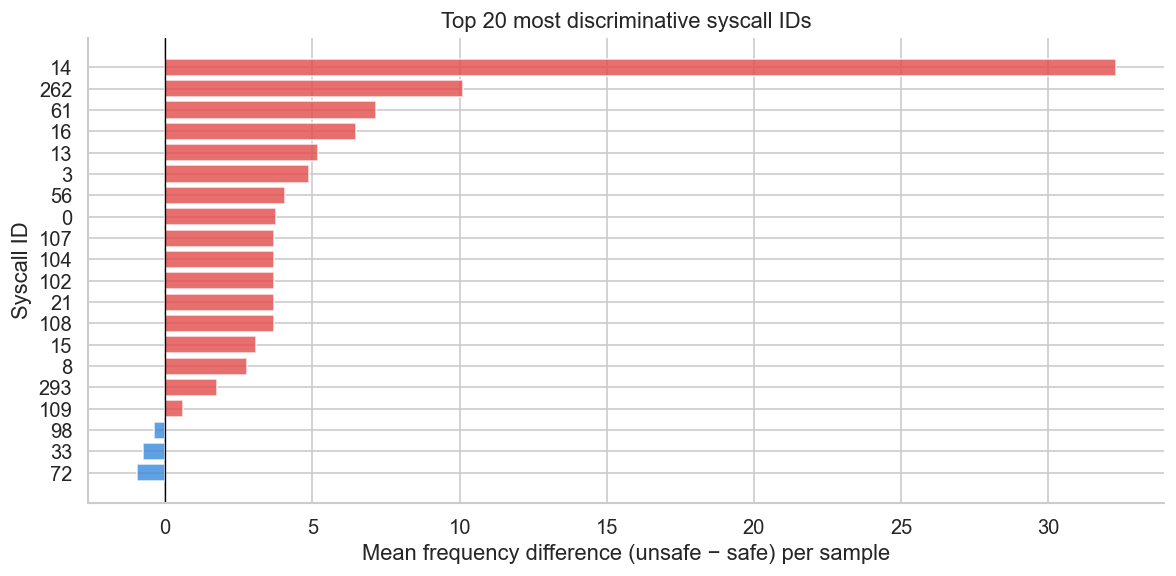

In [12]:
# ── Bar chart: top-N most discriminative syscalls ─────────────────────────────
top_n  = 20
top_df = freq_df.reindex(freq_df['diff'].abs().nlargest(top_n).index)
top_df = top_df.sort_values('diff', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = [UNSAFE_COLOR if d > 0 else SAFE_COLOR for d in top_df['diff']]
ax.barh(top_df['syscall_id'].astype(str), top_df['diff'], color=colors_bar, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean frequency difference (unsafe − safe) per sample')
ax.set_title(f'Top {top_n} most discriminative syscall IDs')
ax.set_ylabel('Syscall ID')
plt.tight_layout()
plt.savefig('../results/figures/05_syscall_frequency_diff.png', bbox_inches='tight')
plt.show()

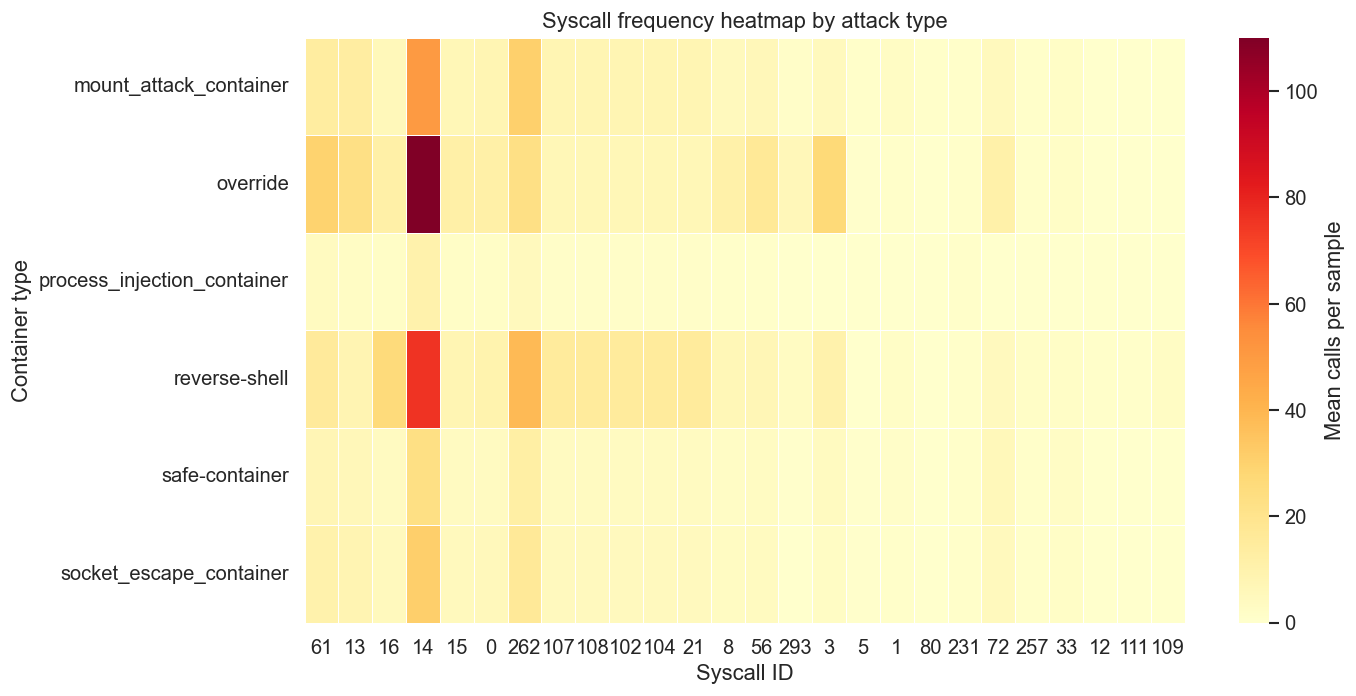

In [13]:
# ── Heatmap: syscall frequency by attack type ─────────────────────────────────
attack_freq = {}
for name, grp in df_sc.groupby('ContainerName'):
    counter = collections.Counter()
    for lst in grp['syscall_list']:
        counter.update(lst)
    n = len(grp)
    attack_freq[name] = {k: v / n for k, v in counter.items()}

heat_df = pd.DataFrame(attack_freq).fillna(0)
# Keep only syscall IDs that appear at a meaningful rate somewhere
heat_df = heat_df[heat_df.max(axis=1) > 0.5]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    heat_df.T,
    cmap='YlOrRd',
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Mean calls per sample'}
)
ax.set_xlabel('Syscall ID')
ax.set_ylabel('Container type')
ax.set_title('Syscall frequency heatmap by attack type')
plt.tight_layout()
plt.savefig('../results/figures/06_syscall_heatmap_by_attack.png', bbox_inches='tight')
plt.show()

---
## 5. Linux capabilities — `AddedCapabilitiesList` & `DroppedCapabilitiesList`

In [14]:
# ── Parse capability lists ────────────────────────────────────────────────────
def parse_caps(series):
    """Strip brackets, split on whitespace, return list of cap names."""
    return series.dropna().apply(lambda x: str(x).strip().strip('[]').split())

df_caps = df.dropna(subset=['AddedCapabilitiesList']).copy()
df_caps['added_caps']       = parse_caps(df_caps['AddedCapabilitiesList'])
df_caps['added_caps_count'] = df_caps['added_caps'].apply(len)

print('Added capabilities count — by class:')
print(df_caps.groupby('IsSafe')['added_caps_count'].describe().round(2))

Added capabilities count — by class:
          count  mean   std  min  25%  50%  75%  max
IsSafe                                              
False   30064.0   4.8  1.94  1.0  5.0  6.0  6.0  6.0
True    31232.0   1.0  0.00  1.0  1.0  1.0  1.0  1.0


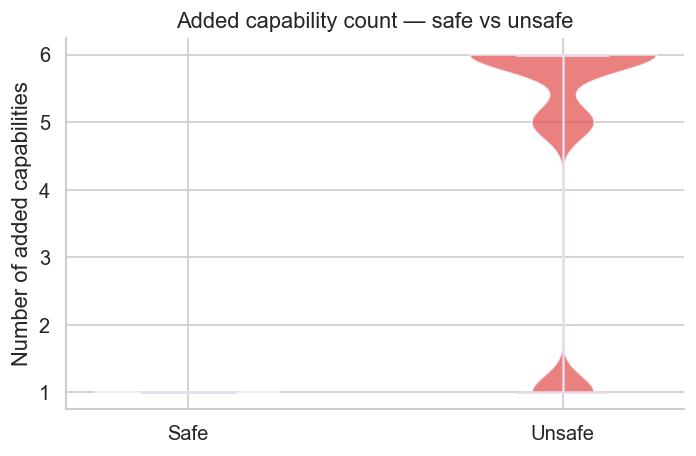


Safe containers always have exactly 1 added capability: True


In [15]:
# ── Capability count — violin plot ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
parts = ax.violinplot(
    [df_caps[df_caps['IsSafe'] == True]['added_caps_count'].values,
     df_caps[df_caps['IsSafe'] == False]['added_caps_count'].values],
    positions=[1, 2],
    showmedians=True
)
for pc, color in zip(parts['bodies'], [SAFE_COLOR, UNSAFE_COLOR]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Safe', 'Unsafe'])
ax.set_ylabel('Number of added capabilities')
ax.set_title('Added capability count — safe vs unsafe')
plt.tight_layout()
plt.savefig('../results/figures/07_capability_count_violin.png', bbox_inches='tight')
plt.show()

print('\nSafe containers always have exactly 1 added capability:', 
      (df_caps[df_caps['IsSafe'] == True]['added_caps_count'] == 1).all())

All unique capability names: ['ALL', 'CHOWN', 'DAC_OVERRIDE', 'DAC_READ_SEARCH', 'FOWNER', 'SETGID', 'SETUID', 'SYS_ADMIN', 'SYS_MODULE', 'SYS_PTRACE']


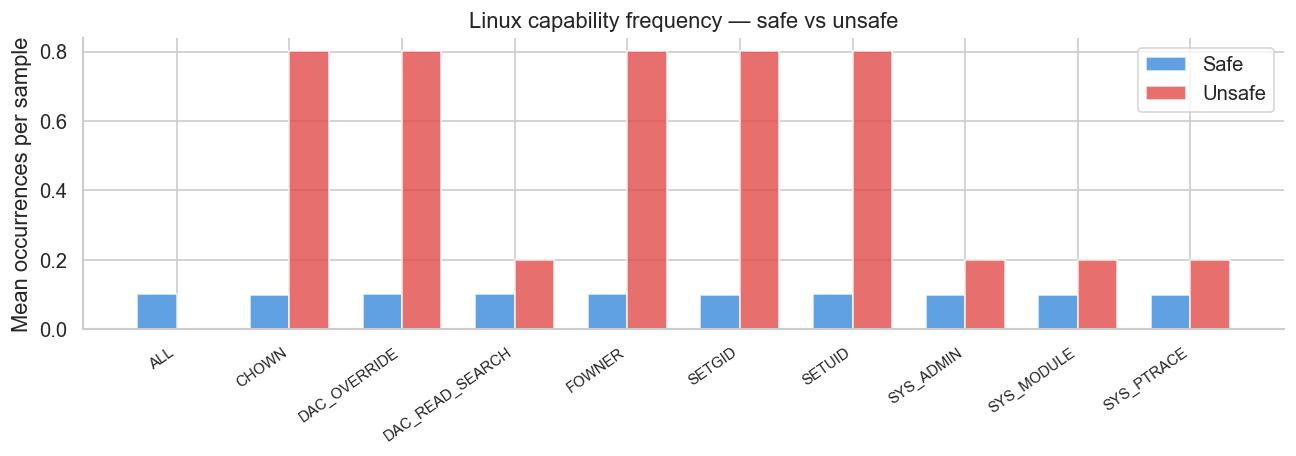

In [16]:
# ── Multi-hot: which capabilities appear in safe vs unsafe ────────────────────
all_cap_names = sorted(set(
    cap for caps in df_caps['added_caps'] for cap in caps
))
print('All unique capability names:', all_cap_names)

# Frequency per class
cap_freq = {}
for is_safe, label in [(True, 'Safe'), (False, 'Unsafe')]:
    sub   = df_caps[df_caps['IsSafe'] == is_safe]
    n     = len(sub)
    counter = collections.Counter(cap for caps in sub['added_caps'] for cap in caps)
    cap_freq[label] = {k: counter[k] / n for k in all_cap_names}

cap_freq_df = pd.DataFrame(cap_freq, index=all_cap_names)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(all_cap_names))
w = 0.35
ax.bar(x - w/2, cap_freq_df['Safe'],   width=w, color=SAFE_COLOR,   alpha=0.8, label='Safe')
ax.bar(x + w/2, cap_freq_df['Unsafe'], width=w, color=UNSAFE_COLOR, alpha=0.8, label='Unsafe')
ax.set_xticks(x)
ax.set_xticklabels(all_cap_names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean occurrences per sample')
ax.set_title('Linux capability frequency — safe vs unsafe')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/08_capability_frequency.png', bbox_inches='tight')
plt.show()

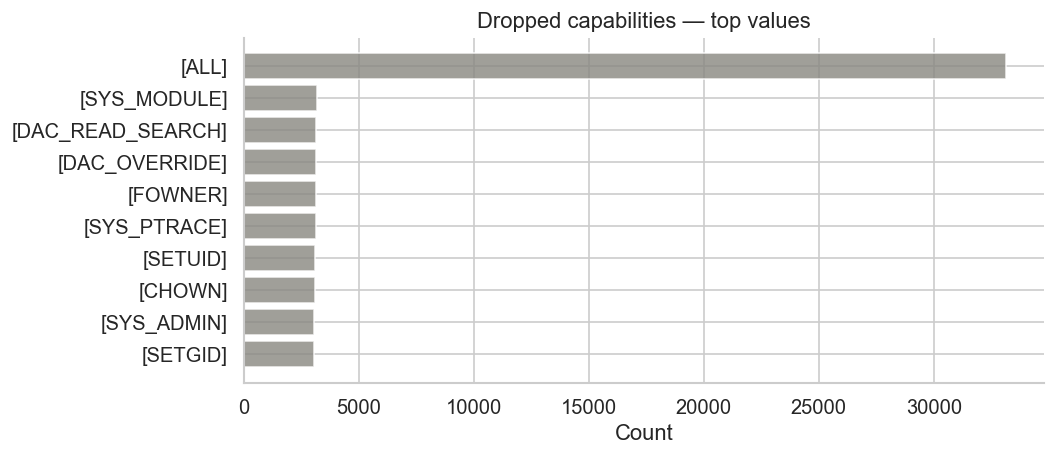

DroppedCapabilitiesList
[ALL]                33151
[SYS_MODULE]          3175
[DAC_READ_SEARCH]     3161
[DAC_OVERRIDE]        3161
[FOWNER]              3152
[SYS_PTRACE]          3136
[SETUID]              3117
[CHOWN]               3112
[SYS_ADMIN]           3072
[SETGID]              3058
Name: count, dtype: int64


In [17]:
# ── Dropped capabilities distribution ─────────────────────────────────────────
df_drop = df.dropna(subset=['DroppedCapabilitiesList']).copy()
drop_counts = df_drop['DroppedCapabilitiesList'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(drop_counts.index, drop_counts.values, color='#888780', alpha=0.8)
ax.set_xlabel('Count')
ax.set_title('Dropped capabilities — top values')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../results/figures/09_dropped_capabilities.png', bbox_inches='tight')
plt.show()

print(drop_counts)

**Observations:**
- Safe containers **always** have exactly 1 added capability. Unsafe containers have 4–6.
- This single feature (`added_caps_count`) is nearly a perfect separator — important to track whether models learn this shortcut vs. real syscall patterns.
- `[ALL]` is the most common dropped capability (safe containers dropping everything before granting one specific cap).

---
## 6. Return values — `ReturnValueList`

> **Note:** This column contains a mix of integers, hex addresses (from `mmap`-type calls), and a literal `?` token. We extract only the integer tokens for analysis.

In [18]:
def parse_retvals(s):
    """Extract only integer tokens (including negative); skip hex addresses and '?'."""
    tokens = str(s).strip().split()
    ints   = []
    for t in tokens:
        if re.match(r'^-?\d+$', t):
            ints.append(int(t))
    return ints

df_rv = df.dropna(subset=['ReturnValueList']).copy()
df_rv['retval_ints']  = df_rv['ReturnValueList'].apply(parse_retvals)
df_rv['retval_len']   = df_rv['retval_ints'].apply(len)
df_rv['error_rate']   = df_rv['retval_ints'].apply(
    lambda x: x.count(-1) / len(x) if x else 0
)
df_rv['pos_rate']     = df_rv['retval_ints'].apply(
    lambda x: sum(v > 0 for v in x) / len(x) if x else 0
)
df_rv['zero_rate']    = df_rv['retval_ints'].apply(
    lambda x: x.count(0) / len(x) if x else 0
)

print('Return value integer count by class:')
print(df_rv.groupby('IsSafe')['retval_len'].describe().round(1))
print('\nError rate (fraction of -1) by class:')
print(df_rv.groupby('IsSafe')['error_rate'].describe().round(4))

Return value integer count by class:
          count   mean    std   min    25%    50%    75%    max
IsSafe                                                         
False   30057.0  197.5  110.7  25.0  110.0  200.0  310.0  363.0
True    31232.0   98.5   22.7   9.0   85.0  102.0  113.0  141.0

Error rate (fraction of -1) by class:
          count    mean     std     min     25%     50%     75%     max
IsSafe                                                                 
False   30057.0  0.0934  0.0209  0.0342  0.0800  0.1000  0.1073  0.1190
True    31232.0  0.0983  0.0181  0.0116  0.0901  0.1034  0.1100  0.1206


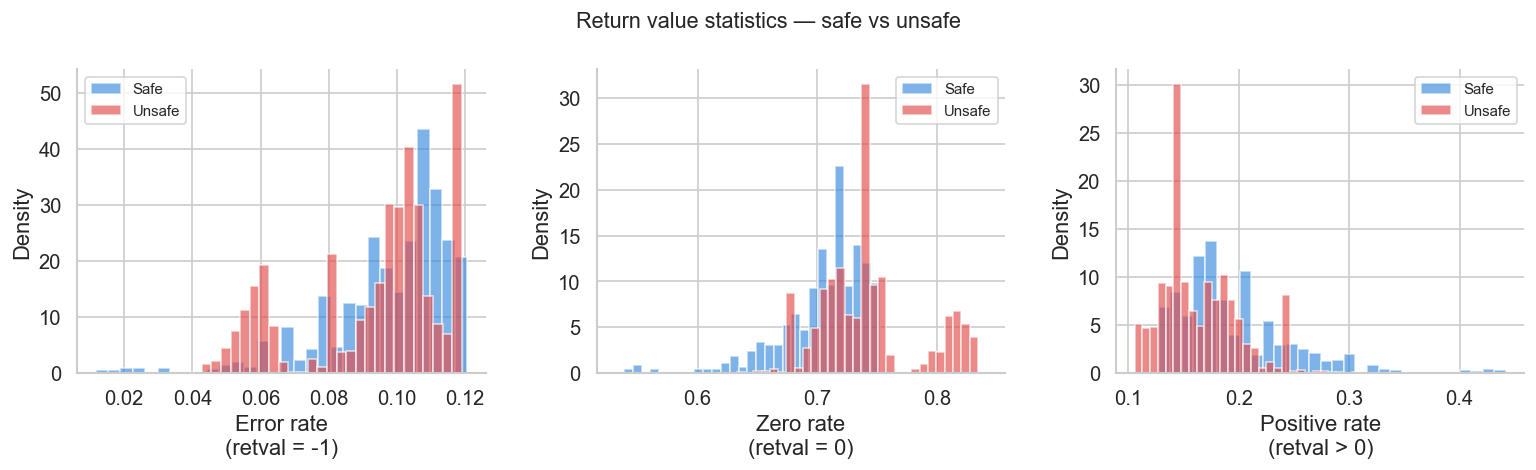

In [19]:
# ── Error rate / zero rate / positive rate comparison ─────────────────────────
metrics = ['error_rate', 'zero_rate', 'pos_rate']
labels  = ['Error rate\n(retval = -1)', 'Zero rate\n(retval = 0)', 'Positive rate\n(retval > 0)']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, label in zip(axes, metrics, labels):
    for is_safe, color, lbl in [(True, SAFE_COLOR, 'Safe'), (False, UNSAFE_COLOR, 'Unsafe')]:
        ax.hist(
            df_rv[df_rv['IsSafe'] == is_safe][col],
            bins=30, alpha=0.65, color=color, label=lbl, density=True
        )
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Return value statistics — safe vs unsafe', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/10_retval_distributions.png', bbox_inches='tight')
plt.show()

**Observation:** Error rate, zero rate, and positive rate distributions are nearly identical between safe and unsafe classes. **Return value statistics are weak discriminators** and will likely add little signal to the model on their own.

---
## 7. Feature correlation overview

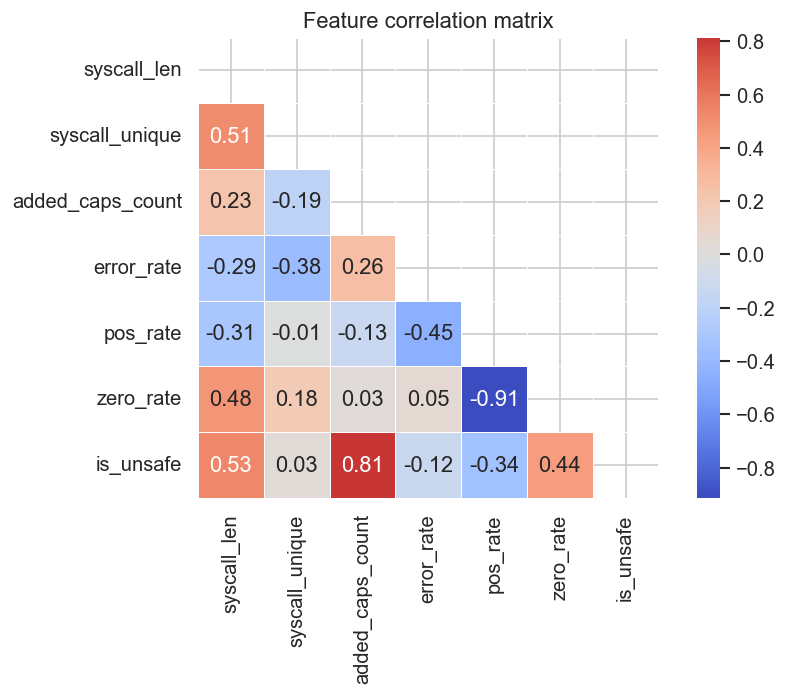

In [20]:
# ── Assemble a flat feature frame for correlation analysis ────────────────────
feature_df = df_sc[['IsSafe', 'syscall_len', 'syscall_unique']].copy()

# Capability count (join on index)
caps_series = df_caps[['added_caps_count']]
feature_df  = feature_df.join(caps_series, how='left')

# Return value features (join on index)
rv_cols    = df_rv[['error_rate', 'pos_rate', 'zero_rate']]
feature_df = feature_df.join(rv_cols, how='left')

# Binary target
feature_df['is_unsafe'] = (~feature_df['IsSafe']).astype(int)
feature_df = feature_df.drop(columns='IsSafe').dropna()

corr = feature_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, square=True
)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('../results/figures/11_correlation_matrix.png', bbox_inches='tight')
plt.show()

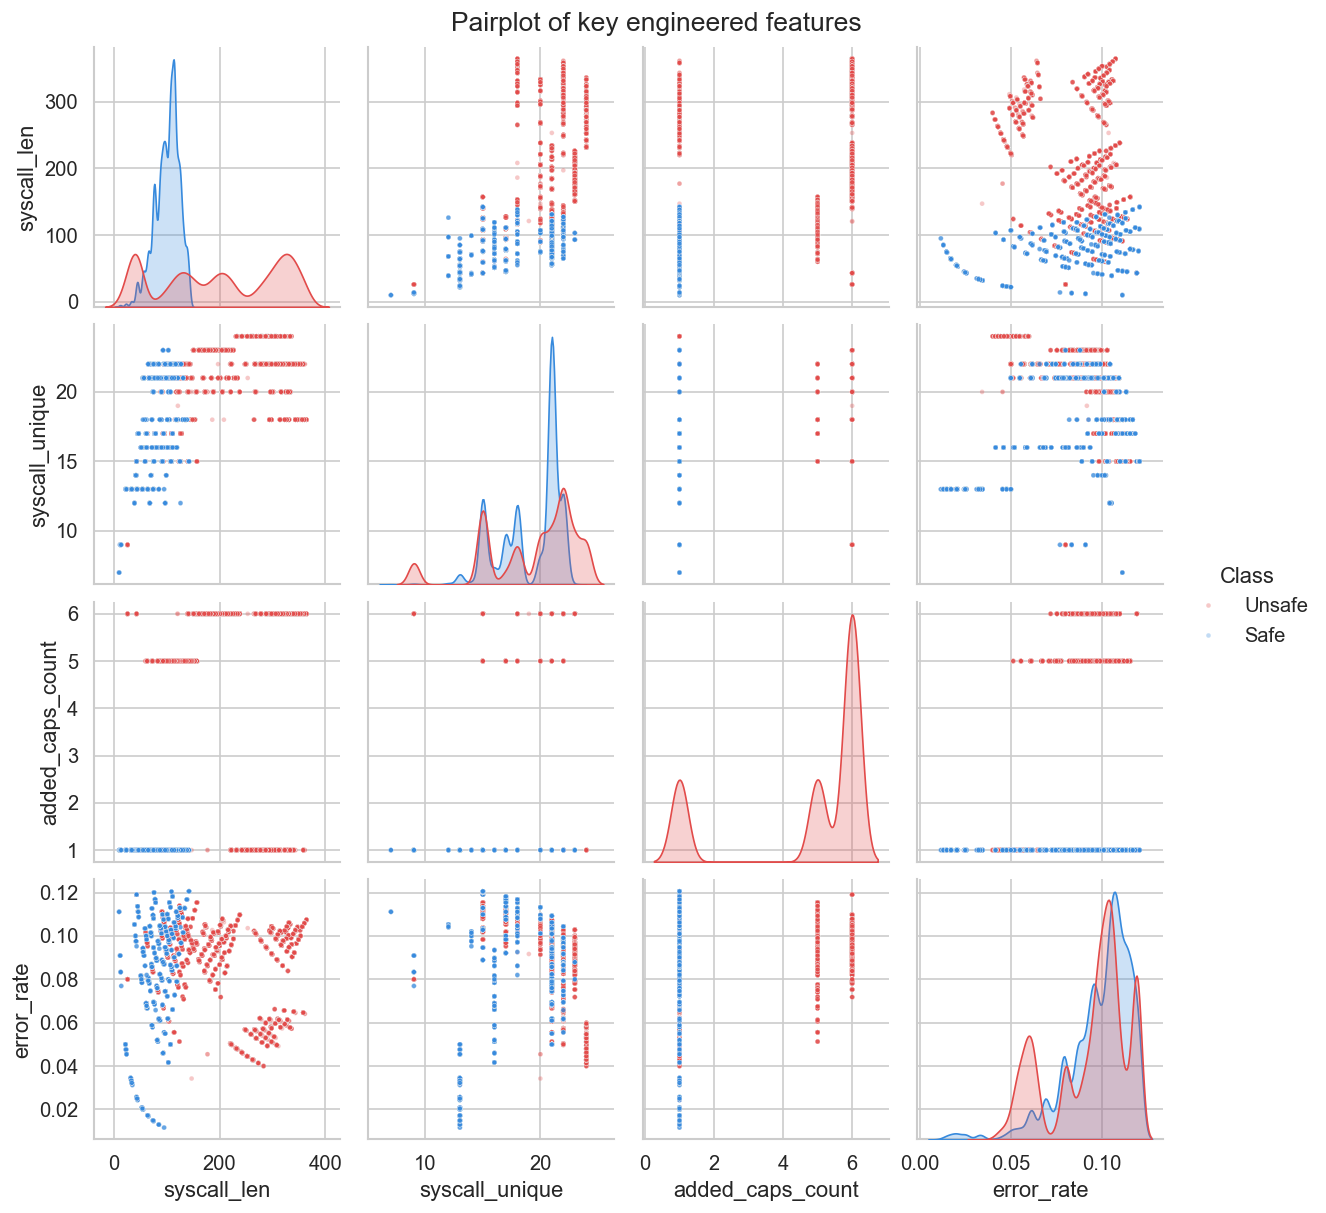

In [21]:
# ── Pairplot of engineered features, coloured by class ───────────────────────
plot_cols = ['syscall_len', 'syscall_unique', 'added_caps_count', 'error_rate', 'is_unsafe']
pp_df     = feature_df[plot_cols].copy()
pp_df['Class'] = pp_df['is_unsafe'].map({0: 'Safe', 1: 'Unsafe'})

g = sns.pairplot(
    pp_df.drop(columns='is_unsafe'),
    hue='Class',
    palette={'Safe': SAFE_COLOR, 'Unsafe': UNSAFE_COLOR},
    plot_kws={'alpha': 0.3, 's': 8},
    diag_kind='kde'
)
g.fig.suptitle('Pairplot of key engineered features', y=1.01)
plt.savefig('../results/figures/12_pairplot.png', bbox_inches='tight')
plt.show()

---
## 8. Syscall sequence length vs. attack type

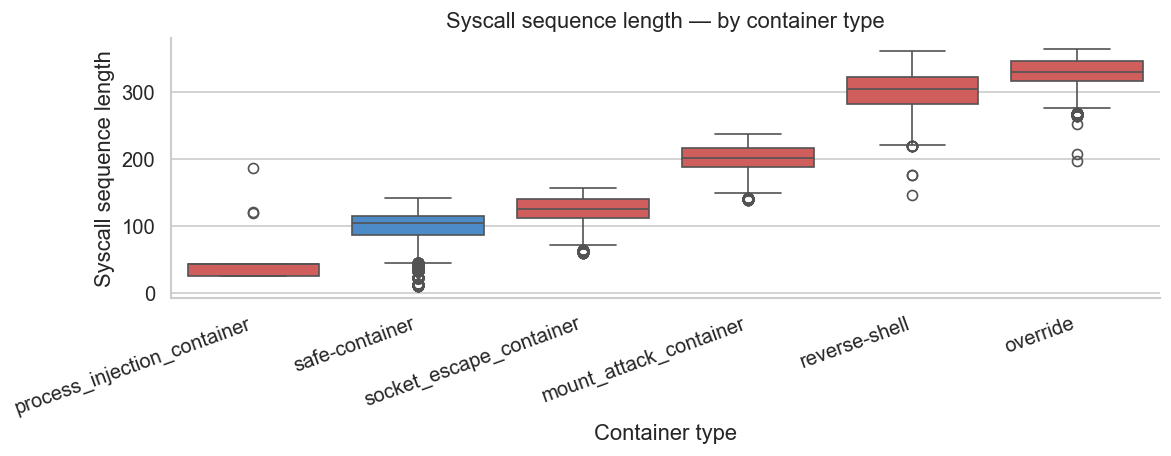

In [22]:
order = df_sc.groupby('ContainerName')['syscall_len'].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    data=df_sc,
    x='ContainerName', y='syscall_len',
    order=order,
    palette={n: (SAFE_COLOR if n == 'safe-container' else UNSAFE_COLOR)
             for n in df_sc['ContainerName'].unique()},
    ax=ax
)
ax.set_xlabel('Container type')
ax.set_ylabel('Syscall sequence length')
ax.set_title('Syscall sequence length — by container type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/13_syscall_len_by_attack.png', bbox_inches='tight')
plt.show()

---
## 9. EDA Summary — key findings for modelling

In [23]:
findings = {
    'Class balance'         : '50.9% safe vs 49.1% unsafe — no resampling needed.',
    'Attack balance'        : '5 attack types, each with ~6 000 samples — balanced multi-class too.',
    'Syscall length'        : 'Unsafe traces are ~2× longer (mean 199 vs 101). Strong feature.',
    'Exclusive syscalls'    : 'IDs 12, 80, 109, 111 appear only in unsafe traces.',
    'Capability count'      : 'Safe always = 1 capability; unsafe = 4–6. Near-perfect separator.',
    'Return values'         : 'Error rate nearly identical across classes — weak discriminator.',
    'Variable-length seqs'  : 'Syscall lists range 10–364 calls → padding or sequence models needed.',
    'Missing data'          : '<12 nulls per column out of 61 K rows — safe to drop.',
    'Hex tokens in retvals' : '"?" and hex addresses in ReturnValueList — filter before numeric analysis.',
}

print('=' * 70)
print('EDA SUMMARY')
print('=' * 70)
for k, v in findings.items():
    print(f'  [{k}]')
    print(f'    → {v}')
    print()
print('=' * 70)

EDA SUMMARY
  [Class balance]
    → 50.9% safe vs 49.1% unsafe — no resampling needed.

  [Attack balance]
    → 5 attack types, each with ~6 000 samples — balanced multi-class too.

  [Syscall length]
    → Unsafe traces are ~2× longer (mean 199 vs 101). Strong feature.

  [Exclusive syscalls]
    → IDs 12, 80, 109, 111 appear only in unsafe traces.

  [Capability count]
    → Safe always = 1 capability; unsafe = 4–6. Near-perfect separator.

  [Return values]
    → Error rate nearly identical across classes — weak discriminator.

  [Variable-length seqs]
    → Syscall lists range 10–364 calls → padding or sequence models needed.

  [Missing data]
    → <12 nulls per column out of 61 K rows — safe to drop.

  [Hex tokens in retvals]
    → "?" and hex addresses in ReturnValueList — filter before numeric analysis.



In [24]:
# ── Save EDA metrics to results/metrics.json ──────────────────────────────────
import json, os

os.makedirs('../results', exist_ok=True)

eda_metrics = {
    'total_rows'            : int(len(df)),
    'n_safe'                : int((df['IsSafe'] == True).sum()),
    'n_unsafe'              : int((df['IsSafe'] == False).sum()),
    'n_attack_types'        : int(df[df['IsSafe'] == False]['ContainerName'].nunique()),
    'syscall_len_mean_safe' : float(df_sc[df_sc['IsSafe'] == True]['syscall_len'].mean().round(2)),
    'syscall_len_mean_unsafe': float(df_sc[df_sc['IsSafe'] == False]['syscall_len'].mean().round(2)),
    'syscall_len_max'       : int(df_sc['syscall_len'].max()),
    'unique_syscall_ids'    : int(len(all_ids)),
    'exclusive_unsafe_ids'  : [int(x) for x in freq_df[freq_df['only_unsafe']]['syscall_id'].tolist()],
    'error_rate_safe'       : float(df_rv[df_rv['IsSafe'] == True]['error_rate'].mean().round(4)),
    'error_rate_unsafe'     : float(df_rv[df_rv['IsSafe'] == False]['error_rate'].mean().round(4)),
    'cap_count_safe_always' : bool((df_caps[df_caps['IsSafe'] == True]['added_caps_count'] == 1).all()),
    'cap_count_unsafe_mean' : float(df_caps[df_caps['IsSafe'] == False]['added_caps_count'].mean().round(2)),
}

with open('../results/metrics.json', 'w') as f:
    json.dump({'eda': eda_metrics}, f, indent=2)

print('Saved to ../results/metrics.json')
print(json.dumps(eda_metrics, indent=2))

Saved to ../results/metrics.json
{
  "total_rows": 61297,
  "n_safe": 31232,
  "n_unsafe": 30065,
  "n_attack_types": 5,
  "syscall_len_mean_safe": 100.58,
  "syscall_len_mean_unsafe": 199.4,
  "syscall_len_max": 364,
  "unique_syscall_ids": 27,
  "exclusive_unsafe_ids": [
    12,
    80,
    109,
    111
  ],
  "error_rate_safe": 0.0983,
  "error_rate_unsafe": 0.0934,
  "cap_count_safe_always": true,
  "cap_count_unsafe_mean": 4.8
}
